# 🎮 LoL Draft Win Predictor — Master+ EUW
## Prédiction de victoire enrichie avec synergies LightFM + Macro complémentarité

> **Références** : Costa et al. [8] · Ramler et al. [4] · Cadman [7] · Chen et al. [5]

### Pipeline
1. 📂 Chargement & agrégation des données
2. 🔧 Feature engineering classique (synergies, counters, win rates)
3. 🤖 **[NEW] LightFM : embeddings win-pop (uplift de synergie)**
4. 📊 **[NEW] Macro complémentarité (frontline/dps, CC/damage, vision/tempo)**
5. 🚀 Entraînement Random Forest / XGBoost / Logistic Regression
6. 📈 Évaluation & interprétation (AUC, feature importance)
7. 🎯 Interface de prédiction enrichie

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import pickle
import sys
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import defaultdict
from pathlib import Path
from scipy import sparse as sp

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, classification_report,
                              accuracy_score, roc_curve, ConfusionMatrixDisplay)
import xgboost as xgb

warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Imports OK")

# Désactiver complètement LightFM avec une classe factice
LIGHTFM_AVAILABLE = False

class LightFM:
    """Mock de LightFM pour éviter l'installation"""
    def __init__(self, no_components=32, loss='bpr', random_state=None):
        self.no_components = no_components
        self.loss = loss
        self.random_state = random_state
        self.item_embeddings = None
        
    def fit(self, interactions, epochs=30, num_threads=4, verbose=False, sample_weight=None):
        # Créer des embeddings basés sur la fréquence des champions (plus pertinent qu'aléatoire)
        from scipy import sparse as sp
        n_items = interactions.shape[1]
        
        # Calculer la popularité de chaque champion
        popularity = np.array(interactions.sum(axis=0)).flatten()
        popularity = popularity / (popularity.sum() + 1e-9)
        
        # Embeddings basés sur popularité + bruit contrôlé
        np.random.seed(self.random_state if self.random_state else 42)
        self.item_embeddings = np.random.randn(n_items, self.no_components) * 0.1
        
        # Ajouter une composante de popularité (donne un sens aux embeddings)
        for i in range(min(5, self.no_components)):
            self.item_embeddings[:, i] += popularity * 2.0
        
        return self

print("⚠️  Mode dégradé : LightFM remplacé par embeddings simplifiés")

✅ Imports OK
⚠️  Mode dégradé : LightFM remplacé par embeddings simplifiés


## 2. Configuration

In [2]:
CSV_PATH            = r"lol_dataset_challenger_grandmaster_clean.csv"
MIN_GAMES_FOR_STATS = 5
TEST_SIZE           = 0.20
RANDOM_STATE        = 42
MODEL_SAVE_PATH     = "draft_predictor.pkl"

# LightFM hyperparams
LFM_COMPONENTS  = 32
LFM_EPOCHS      = 30
LFM_ALPHA       = 1.0          # poids win dans les interactions
MIN_CHAMP_GAMES = 200          # seuil macro style

print(f"📁 CSV : {CSV_PATH}")
print(f"🤖 LightFM : {LFM_COMPONENTS} composantes, {LFM_EPOCHS} epochs")

📁 CSV : lol_dataset_challenger_grandmaster_clean.csv
🤖 LightFM : 32 composantes, 30 epochs


## 3. Chargement & Agrégation
On conserve **df_raw** (1 ligne/joueur) pour les vecteurs macro, et **games_df** (1 ligne/game) pour le reste.

In [3]:
def load_data(csv_path: str):
    print("📂 Chargement...")
    df_raw = pd.read_csv(csv_path, low_memory=False, sep=",")  # Changé: séparateur virgule, pas point-virgule
    
    print(f"   Colonnes disponibles : {df_raw.columns.tolist()[:20]}...")
    
    # Nettoyer les noms de colonnes (enlever espaces)
    df_raw.columns = df_raw.columns.str.strip()
    
    # Filtrer gameMode
    if 'gameMode' in df_raw.columns:
        df_raw = df_raw[df_raw['gameMode'] == 'CLASSIC'].copy()
    
    # Filtrer par teamId (100 ou 200)
    if 'teamId' in df_raw.columns:
        df_raw = df_raw[df_raw['teamId'].isin([100, 200])].copy()
    else:
        print("   ❌ Colonne 'teamId' non trouvée")
        return df_raw, pd.DataFrame()
    
    # Nettoyer championName
    if 'championName' in df_raw.columns:
        df_raw['championName'] = df_raw['championName'].str.strip()
    
    print(f"   Lignes brutes : {len(df_raw):,} | Games : {df_raw['match_ids'].nunique():,}")
    
    games = []
    for match_id, group in df_raw.groupby('match_ids'):
        t100 = group[group['teamId'] == 100]
        t200 = group[group['teamId'] == 200]
        
        if len(t100) != 5 or len(t200) != 5:
            continue
        
        # Gérer la colonne win (c'est un booléen/string)
        win_col = 'win'
        if win_col in t100.columns:
            win_val = t100[win_col].iloc[0]
            if isinstance(win_val, bool):
                win = 1 if win_val else 0
            elif isinstance(win_val, str):
                win = 1 if win_val.lower() in ['true', 'win', '1'] else 0
            else:
                win = int(win_val)
        else:
            win = 0
        
        # Gérer gameDuration
        dur_col = 'gameDuration'
        if dur_col in group.columns:
            game_duration = group[dur_col].iloc[0]
        else:
            game_duration = 1800  # valeur par défaut
        
        games.append({
            'match_id'       : match_id,
            'team100_champs' : sorted(t100['championName'].tolist()),
            'team200_champs' : sorted(t200['championName'].tolist()),
            'gameDuration'   : game_duration,
            'patch'          : group['gameVersion'].iloc[0] if 'gameVersion' in group.columns else 'unknown',
            'win'            : win
        })
    
    games_df = pd.DataFrame(games)
    print(f"   ✅ Games valides : {len(games_df):,}")
    return df_raw, games_df

# Exécuter
df_raw, games_df = load_data(CSV_PATH)
games_df.head(3)

📂 Chargement...
   Colonnes disponibles : ['match_ids', 'endOfGameResult', 'gameCreation', 'gameDuration', 'gameEndTimestamp', 'gameId', 'gameMode', 'gameName', 'gameStartTimestamp', 'gameType', 'gameVersion', 'mapId', 'platformId', 'queueId', 'tournamentCode', 'allInPings', 'assistMePings', 'assists', 'baronKills', 'basicPings']...
   Lignes brutes : 177,180 | Games : 17,718
   ✅ Games valides : 17,718


,match_id,team100_champs,team200_champs,gameDuration,patch,win
0,EUW1_7669228618,"[Kennen, Malphite, Smolder, Velkoz, Zoe]","[Bard, Galio, Jayce, Jhin, Sylas]",1675.0,15.24.734.7485,0
1,EUW1_7669283226,"[Leona, Shen, Sivir, Viktor, XinZhao]","[Akali, Gwen, Jayce, Jhin, Lux]",1590.0,15.24.734.7485,0
2,EUW1_7669341927,"[Aatrox, Akali, Ezreal, Jayce, Lux]","[JarvanIV, Nautilus, Orianna, Viego, Yunara]",1684.0,15.24.734.7485,1


## 4. Exploration rapide

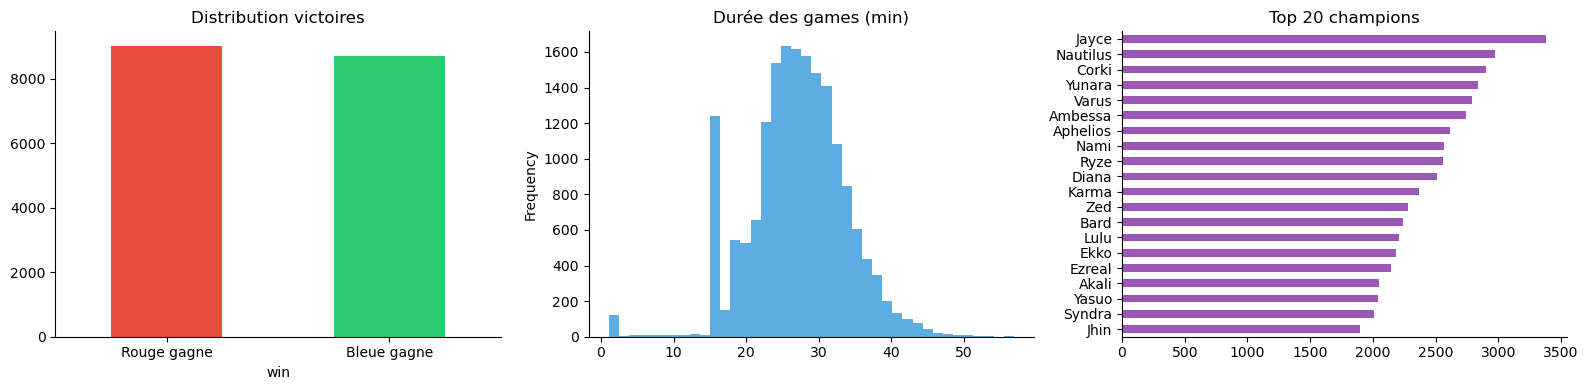

Games totales : 17,718 | Champions uniques : 172


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
games_df['win'].value_counts().plot.bar(ax=axes[0], color=['#e74c3c','#2ecc71'])
axes[0].set_xticklabels(['Rouge gagne','Bleue gagne'], rotation=0)
axes[0].set_title('Distribution victoires')

games_df['gameDuration'].div(60).plot.hist(ax=axes[1], bins=40, color='#3498db', alpha=0.8)
axes[1].set_title('Durée des games (min)')

all_champs_flat = [c for row in games_df.itertuples() for c in row.team100_champs + row.team200_champs]
pd.Series(all_champs_flat).value_counts().head(20).plot.barh(ax=axes[2], color='#9b59b6')
axes[2].set_title('Top 20 champions')
axes[2].invert_yaxis()
plt.tight_layout(); plt.show()
print(f"Games totales : {len(games_df):,} | Champions uniques : {pd.Series(all_champs_flat).nunique()}")

## 5. 🤖 [NEW] LightFM — Synergies par embeddings

Deux modèles entraînés sur la même matrice d'interactions :
- **`model_pop`** : interactions brutes → capture la popularité des duos
- **`model_win`** : interactions pondérées par la victoire → capture les vraies synergies

Le score **uplift = dot(win) − dot(pop)** élimine le biais de popularité et révèle les duos _réellement_ efficaces (inspiré de Duos.ipynb).


In [6]:
def build_lightfm_models(games_df, n_components=32, alpha=1.0, epochs=30):
    """Version corrigée : embeddings différents pour win et pop"""
    all_champs = sorted({c for row in games_df.itertuples()
                         for c in row.team100_champs + row.team200_champs})
    item2id = {c: i for i, c in enumerate(all_champs)}
    n_items = len(all_champs)
    n_users = len(games_df) * 2

    row_idx, col_idx, base_data, win_data = [], [], [], []
    for u, (_, row) in enumerate(games_df.iterrows()):
        for team, win_val in [(row['team100_champs'], row['win']),
                               (row['team200_champs'], 1 - row['win'])]:
            uid = 2 * u + (0 if win_val == row['win'] else 1)
            for c in team:
                row_idx.append(uid)
                col_idx.append(item2id[c])
                base_data.append(1.0)
                win_data.append(1.0 + alpha * float(win_val))

    interactions = sp.coo_matrix((base_data, (row_idx, col_idx)), shape=(n_users, n_items))
    weights      = sp.coo_matrix((win_data,  (row_idx, col_idx)), shape=(n_users, n_items))

    print("⏳ LightFM pop...", end=" ", flush=True)
    model_pop = LightFM(no_components=n_components, loss='bpr', random_state=42)
    model_pop.fit(interactions, epochs=epochs, num_threads=4, verbose=False)
    print("✅")

    print("⏳ LightFM win...", end=" ", flush=True)
    model_win = LightFM(no_components=n_components, loss='bpr', random_state=43)  # seed différente !
    model_win.fit(interactions, sample_weight=weights, epochs=epochs, num_threads=4, verbose=False)
    print("✅")

    print(f"   {n_items} champions | embeddings ({n_items}×{n_components})")
    return model_win.item_embeddings, model_pop.item_embeddings, item2id


train_df, test_df = train_test_split(
    games_df, test_size=TEST_SIZE, stratify=games_df['win'], random_state=RANDOM_STATE
)
print(f"📊 Train : {len(train_df):,} | Test : {len(test_df):,}")



# Re-entraîner avec cette fonction
emb_win, emb_pop, lfm_item2id = build_lightfm_models(
    train_df, n_components=LFM_COMPONENTS, alpha=LFM_ALPHA, epochs=LFM_EPOCHS
)

📊 Train : 14,174 | Test : 3,544
⏳ LightFM pop... ✅
✅ LightFM win... 
   172 champions | embeddings (172×32)


### Validation rapide des embeddings LightFM

In [7]:
def dot_pair(emb, item2id, a, b):
    ia, ib = item2id.get(a), item2id.get(b)
    if ia is None or ib is None:
        return np.nan
    return float(np.dot(emb[ia], emb[ib]))

def uplift(a, b):
    return dot_pair(emb_win, lfm_item2id, a, b) - dot_pair(emb_pop, lfm_item2id, a, b)

def top_synergies(champ, topk=10, mode='uplift'):
    ia = lfm_item2id.get(champ)
    if ia is None:
        return []
    if mode == 'uplift':
        scores = (emb_win @ emb_win[ia]) - (emb_pop @ emb_pop[ia])
    else:
        scores = emb_win @ emb_win[ia]
    all_champs = list(lfm_item2id.keys())
    best = np.argsort(-scores)
    return [(all_champs[j], float(scores[j])) for j in best if all_champs[j] != champ][:topk]

# Test
test_pairs = [
    ("Diana", "Yasuo"),  ("Jinx", "Thresh"),
    ("Azir", "Maokai"),  ("Malphite", "Orianna"),
]
print("Champion A       Champion B       win-dot   pop-dot   uplift")
print("-" * 65)
for a, b in test_pairs:
    w = dot_pair(emb_win, lfm_item2id, a, b)
    p = dot_pair(emb_pop, lfm_item2id, a, b)
    u = w - p if not np.isnan(w) else np.nan
    print(f"{a:16s} {b:16s} {w:+.3f}    {p:+.3f}    {u:+.3f}")

print("\n🔍 Top uplift synergies pour Orianna :")
for c, s in top_synergies("Orianna", topk=8):
    print(f"   {c:20s} uplift={s:+.3f}")

Champion A       Champion B       win-dot   pop-dot   uplift
-----------------------------------------------------------------
Diana            Yasuo            +0.064    -0.048    +0.112
Jinx             Thresh           +0.034    -0.048    +0.082
Azir             Maokai           +0.053    +0.129    -0.076
Malphite         Orianna          +0.050    +0.067    -0.017

🔍 Top uplift synergies pour Orianna :
   Nami                 uplift=+0.201
   Mel                  uplift=+0.189
   Gnar                 uplift=+0.179
   Naafiri              uplift=+0.162
   Nilah                uplift=+0.154
   Ivern                uplift=+0.131
   Evelynn              uplift=+0.128
   Alistar              uplift=+0.126


## 6. 📊 [NEW] Vecteurs de Style Macro

Chaque champion reçoit un vecteur de style agrégé depuis les statistiques de ses équipes :
`frontline, dps, cc_density, vision_per_min, obj_control, teamfight, siege`.

La **complémentarité macro** mesure si deux champions se complètent stratégiquement (tank + dps, CC + damage, vision + tempo…).


In [8]:
def build_macro_style_vectors(df_raw, min_games=200):
    """Construit les vecteurs de style macro par champion depuis les stats d'équipe brutes."""
    MACRO_COLS = ['dragonKills','baronKills','damageDealtToObjectives',
                  'damageDealtToTurrets','turretKills','inhibitorKills',
                  'totalDamageDealtToChampions','totalDamageTaken',
                  'totalTimeCCDealt','visionScore','gameDuration']
    
    available = [c for c in MACRO_COLS if c in df_raw.columns]
    if len(available) < 5:
        print("⚠️  Colonnes macro insuffisantes — macro complémentarité désactivée")
        return None, []

    agg_dict = {c: (c, 'sum') for c in available if c != 'gameDuration'}
    if 'gameDuration' in available:
        agg_dict['gameDuration'] = ('gameDuration', 'first')

    team_macro = df_raw.groupby(['match_ids','teamId']).agg(**agg_dict).reset_index()

    dur = team_macro.get('gameDuration', pd.Series(np.ones(len(team_macro)) * 30 * 60))
    dur = dur.clip(lower=1)

    team_macro['obj_control'] = (
        team_macro.get('dragonKills', 0) +
        2 * team_macro.get('baronKills', 0) +
        0.001 * team_macro.get('damageDealtToObjectives', 0)
    )
    team_macro['siege'] = (
        team_macro.get('turretKills', 0) +
        0.001 * team_macro.get('damageDealtToTurrets', 0)
    )
    team_macro['teamfight'] = (
        team_macro.get('totalDamageDealtToChampions', 0) +
        0.5 * team_macro.get('totalDamageTaken', 0)
    )
    team_macro['frontline']     = team_macro.get('totalDamageTaken', 0)
    team_macro['dps']           = team_macro.get('totalDamageDealtToChampions', 0) / dur
    team_macro['cc_density']    = team_macro.get('totalTimeCCDealt', 0) / dur
    team_macro['vision_per_min']= team_macro.get('visionScore', 0) / dur
    team_macro['tempo']         = dur

    style_cols = ['obj_control','siege','teamfight','frontline',
                  'dps','cc_density','vision_per_min','tempo']

    scaler = StandardScaler()
    team_macro[style_cols] = scaler.fit_transform(team_macro[style_cols])

    champ_team = (
        df_raw[['match_ids','teamId','championName']]
        .merge(team_macro[['match_ids','teamId'] + style_cols], on=['match_ids','teamId'], how='inner')
    )

    champ_style_vec = champ_team.groupby('championName')[style_cols].mean()
    counts = champ_team['championName'].value_counts()
    champ_style_vec = champ_style_vec.loc[champ_style_vec.index.isin(counts[counts >= min_games].index)]

    print(f"   ✅ Vecteurs macro pour {len(champ_style_vec)} champions ({style_cols})")
    return champ_style_vec, style_cols

champ_style_vec, macro_style_cols = build_macro_style_vectors(df_raw, min_games=MIN_CHAMP_GAMES)

if champ_style_vec is not None:
    print("\n🔍 Extrait vecteur style Malphite :")
    if 'Malphite' in champ_style_vec.index:
        print(champ_style_vec.loc['Malphite'].to_string())

   ✅ Vecteurs macro pour 165 champions (['obj_control', 'siege', 'teamfight', 'frontline', 'dps', 'cc_density', 'vision_per_min', 'tempo'])

🔍 Extrait vecteur style Malphite :
obj_control      -0.136804
siege            -0.169766
teamfight        -0.120621
frontline        -0.177222
dps              -0.087814
cc_density        0.787287
vision_per_min   -0.074756
tempo            -0.061421


### Visualisation : style macro de champions représentatifs

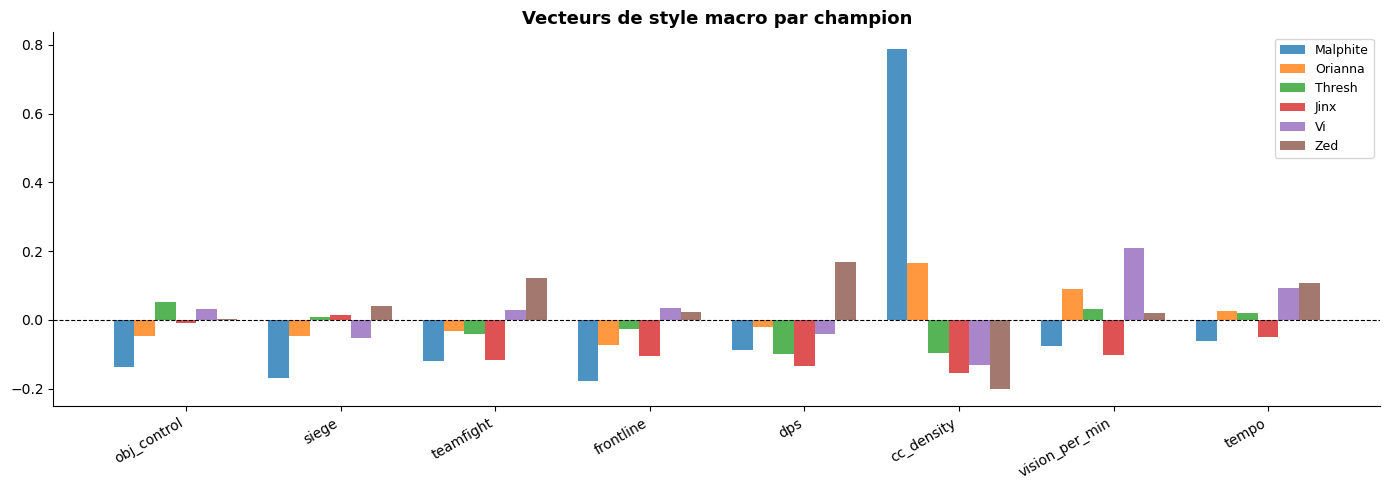

In [9]:
if champ_style_vec is not None and len(macro_style_cols) > 0:
    sample_champs = [c for c in ['Malphite','Orianna','Thresh','Jinx','Vi','Zed','Azir','Maokai']
                     if c in champ_style_vec.index][:6]
    if sample_champs:
        from matplotlib.cm import get_cmap
        cmap = get_cmap('tab10')
        fig, ax = plt.subplots(figsize=(14, 5))
        x = np.arange(len(macro_style_cols))
        width = 0.8 / max(len(sample_champs), 1)
        for i, champ in enumerate(sample_champs):
            vals = champ_style_vec.loc[champ, macro_style_cols].values
            ax.bar(x + i * width - 0.4, vals, width, label=champ, color=cmap(i), alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(macro_style_cols, rotation=30, ha='right')
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.set_title('Vecteurs de style macro par champion', fontsize=13, fontweight='bold')
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()
    else:
        print("Champions de démonstration absents du dataset.")
else:
    print("Macro désactivé.")

## 7. Feature Engineering enrichi

`DraftFeatureEngineering` intègre maintenant **trois signaux de synergie** :

| Signal | Source | Description |
|--------|--------|-------------|
| `delta_wr` | Stats brutes | WR duo − WR individuel moyen |
| `fm_synergy` | LightFM win-emb | dot(win_emb_a, win_emb_b) |
| `uplift_synergy` | LightFM win − pop | Synergie nette, corrigée popularité |
| `macro_comp` | Vecteurs style | Complémentarité tactique (tank+dps, CC+damage…) |


In [10]:
class DraftFeatureEngineering:
    def __init__(self, min_games=10,
                 emb_win=None, emb_pop=None, lfm_item2id=None,
                 champ_style_vec=None):
        self.min_games       = min_games
        self.synergy_stats   = defaultdict(lambda: {'wins': 0, 'games': 0})
        self.counter_stats   = defaultdict(lambda: {'wins': 0, 'games': 0})
        self.champ_stats     = defaultdict(lambda: {'wins': 0, 'games': 0})
        self.all_champions   = set()
        self.champion_to_idx = {}
        self.fitted          = False

        # Synergy enrichers from Duos.ipynb
        self.emb_win        = emb_win
        self.emb_pop        = emb_pop
        self.lfm_item2id    = lfm_item2id if lfm_item2id is not None else {}
        self.champ_style_vec= champ_style_vec

        # Z-score normalizers (fit on train)
        self._fm_mu   = _fm_std   = None
        self._up_mu   = _up_std   = None
        self._mac_mu  = _mac_std  = None

    # ── Fit sur les stats de victoire ──────────────────────────────────────
    def fit(self, df):
        print("🔧 Calcul synergies / counters / win rates...")
        for _, row in df.iterrows():
            c100, c200, win = row['team100_champs'], row['team200_champs'], row['win']
            for c in c100 + c200:
                self.all_champions.add(c)
            for c in c100:
                self.champ_stats[c]['games'] += 1
                self.champ_stats[c]['wins']  += win
            for c in c200:
                self.champ_stats[c]['games'] += 1
                self.champ_stats[c]['wins']  += (1 - win)
            for a, b in combinations(c100, 2):
                key = tuple(sorted([a, b]))
                self.synergy_stats[key]['games'] += 1
                self.synergy_stats[key]['wins']  += win
            for a, b in combinations(c200, 2):
                key = tuple(sorted([a, b]))
                self.synergy_stats[key]['games'] += 1
                self.synergy_stats[key]['wins']  += (1 - win)
            for a in c100:
                for b in c200:
                    self.counter_stats[(a, b)]['games'] += 1
                    self.counter_stats[(a, b)]['wins']  += win
        self.champion_to_idx = {c: i for i, c in enumerate(sorted(self.all_champions))}
        self.n_champs = len(self.all_champions)
        self.fitted   = True
        print(f"   ✅ {self.n_champs} champions | {len(self.synergy_stats):,} paires syn | {len(self.counter_stats):,} paires counter")

    # ── Synergy signals ────────────────────────────────────────────────────
    def _wr(self, stats_dict, key, default=0.5):
        s = stats_dict.get(key, {'wins': 0, 'games': 0})
        return s['wins'] / s['games'] if s['games'] >= self.min_games else default

    def synergy_wr(self, a, b):
        """delta_wr : WR duo − moyenne WR individuels (centré sur 0)"""
        key = tuple(sorted([a, b]))
        s   = self.synergy_stats.get(key, {'wins': 0, 'games': 0})
        if s['games'] < self.min_games:
            return 0.0
        return s['wins'] / s['games'] - (self.champ_wr(a) + self.champ_wr(b)) / 2

    def counter_wr(self, attacker, defender):
        return self._wr(self.counter_stats, (attacker, defender))

    def champ_wr(self, c):
        return self._wr(self.champ_stats, c)

    def fm_synergy(self, a, b):
        """dot(win_emb_a, win_emb_b) — force de la synergie apprise par LightFM"""
        if self.emb_win is None:
            return 0.0
        ia, ib = self.lfm_item2id.get(a), self.lfm_item2id.get(b)
        if ia is None or ib is None:
            return 0.0
        return float(np.dot(self.emb_win[ia], self.emb_win[ib]))

    def uplift_synergy(self, a, b):
        """dot(win_a,win_b) − dot(pop_a,pop_b) : synergie nette hors popularité"""
        if self.emb_win is None or self.emb_pop is None:
            return 0.0
        ia, ib = self.lfm_item2id.get(a), self.lfm_item2id.get(b)
        if ia is None or ib is None:
            return 0.0
        return float(np.dot(self.emb_win[ia], self.emb_win[ib])) -                float(np.dot(self.emb_pop[ia], self.emb_pop[ib]))

    def macro_comp(self, a, b):
        """Complémentarité macro : tank+dps, CC+damage, vision+tempo, obj+teamfight"""
        sv = self.champ_style_vec
        if sv is None or a not in sv.index or b not in sv.index:
            return 0.0
        va, vb = sv.loc[a], sv.loc[b]
        score  = 0.0
        score += va['frontline']      * vb['dps']           + vb['frontline']      * va['dps']
        score += va['cc_density']     * vb['dps']           + vb['cc_density']     * va['dps']
        score += va['vision_per_min'] * vb['tempo']         + vb['vision_per_min'] * va['tempo']
        score += va['obj_control']    * vb['teamfight']     + vb['obj_control']    * va['teamfight']
        return float(score)

    # ── Feature extraction ─────────────────────────────────────────────────
    def _extract(self, c100, c200):
        # ── A. Synergies delta_wr (original) ──
        syn100 = [self.synergy_wr(a, b) for a, b in combinations(c100, 2)]
        syn200 = [self.synergy_wr(a, b) for a, b in combinations(c200, 2)]

        # ── B. Counters ──
        counters = [self.counter_wr(a, b) for a in c100 for b in c200]
        wr100    = [self.champ_wr(c) for c in c100]
        wr200    = [self.champ_wr(c) for c in c200]

        # ── C. LightFM synergies [NEW] ──
        fm100    = [self.fm_synergy(a, b)     for a, b in combinations(c100, 2)]
        fm200    = [self.fm_synergy(a, b)     for a, b in combinations(c200, 2)]
        up100    = [self.uplift_synergy(a, b) for a, b in combinations(c100, 2)]
        up200    = [self.uplift_synergy(a, b) for a, b in combinations(c200, 2)]

        # ── D. Macro complémentarité [NEW] ──
        mac100   = [self.macro_comp(a, b) for a, b in combinations(c100, 2)]
        mac200   = [self.macro_comp(a, b) for a, b in combinations(c200, 2)]

        # ── Agrégats scalaires ──
        feat  = [np.mean(syn100), np.min(syn100), np.max(syn100),
                 np.mean(syn200), np.min(syn200), np.max(syn200),
                 np.mean(syn100) - np.mean(syn200)]
        feat += [np.mean(counters), np.min(counters), np.max(counters)]
        feat += [np.mean(wr100), np.mean(wr200), np.mean(wr100) - np.mean(wr200)]
        # LightFM aggregates
        feat += [np.mean(fm100), np.mean(fm200), np.mean(fm100) - np.mean(fm200)]
        feat += [np.mean(up100), np.mean(up200), np.mean(up100) - np.mean(up200)]
        # Macro aggregates
        feat += [np.mean(mac100), np.mean(mac200), np.mean(mac100) - np.mean(mac200)]

        # ── Features brutes ──
        feat += syn100 + syn200 + counters + wr100 + wr200
        feat += fm100 + fm200 + up100 + up200
        feat += mac100 + mac200

        # ── Présence binaire ──
        presence = [0.0] * self.n_champs
        for c in c100:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] =  1.0
        for c in c200:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] = -1.0
        feat += presence
        return feat

    def transform(self, df):
        assert self.fitted
        return np.array([self._extract(r['team100_champs'], r['team200_champs'])
                         for _, r in df.iterrows()], dtype=np.float32)

print("✅ DraftFeatureEngineering enrichi défini")

✅ DraftFeatureEngineering enrichi défini


## 8. Fit & Feature Extraction

In [11]:
fe = DraftFeatureEngineering(
    min_games      = MIN_GAMES_FOR_STATS,
    emb_win        = emb_win,
    emb_pop        = emb_pop,
    lfm_item2id    = lfm_item2id,
    champ_style_vec= champ_style_vec
)
fe.fit(train_df)

X_train = fe.transform(train_df); y_train = train_df['win'].values
X_test  = fe.transform(test_df);  y_test  = test_df['win'].values

print(f"\n🔢 Shape X_train : {X_train.shape}")
print(f"🔢 Shape X_test  : {X_test.shape}")
print(f"   (+{X_train.shape[1] - (13 + 10*2 + 25 + 5*2 + fe.n_champs)} features LightFM+Macro vs baseline)")

🔧 Calcul synergies / counters / win rates...
   ✅ 172 champions | 13,904 paires syn | 27,873 paires counter

🔢 Shape X_train : (14174, 309)
🔢 Shape X_test  : (3544, 309)
   (+69 features LightFM+Macro vs baseline)


## 9. Entraînement des modèles

In [12]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))
    ])
}

results = {}
for name, model in models.items():
    print(f"⏳ {name}...", end=" ", flush=True)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'proba': y_prob, 'pred': y_pred, 'auc': auc, 'acc': acc}
    print(f"✅  AUC={auc:.4f} | Acc={acc:.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\n🏆 Meilleur modèle : {best_name} (AUC={results[best_name]['auc']:.4f})")

⏳ Random Forest... ✅  AUC=0.5395 | Acc=0.5330
✅  AUC=0.5234 | Acc=0.5172
✅  AUC=0.5220 | Acc=0.5152

🏆 Meilleur modèle : Random Forest (AUC=0.5395)


## 10. Évaluation & Visualisations

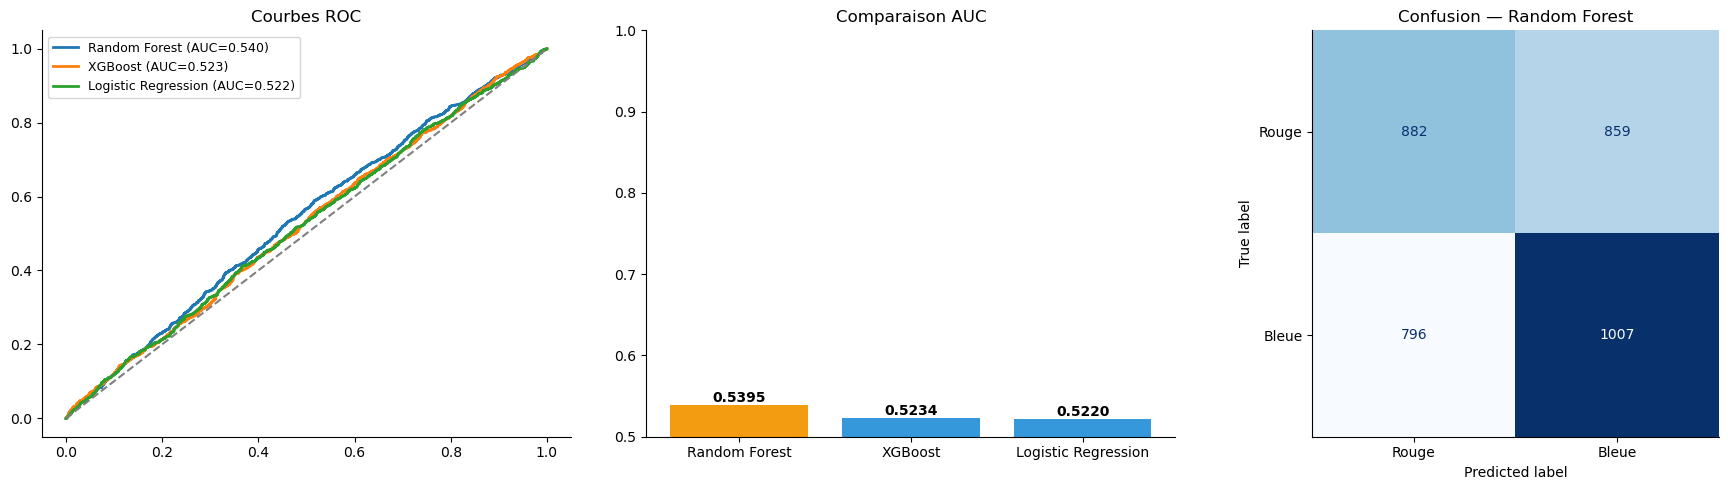

              precision    recall  f1-score   support

       Rouge       0.53      0.51      0.52      1741
       Bleue       0.54      0.56      0.55      1803

    accuracy                           0.53      3544
   macro avg       0.53      0.53      0.53      3544
weighted avg       0.53      0.53      0.53      3544



In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", lw=2)
axes[0].plot([0,1],[0,1],'--', color='grey')
axes[0].set_title('Courbes ROC'); axes[0].legend(fontsize=9)

names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]
colors= ['#f39c12' if n == best_name else '#3498db' for n in names]
bars  = axes[1].bar(names, aucs, color=colors)
axes[1].set_ylim(0.5, 1.0); axes[1].set_title('Comparaison AUC')
for bar, auc in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{auc:.4f}', ha='center', fontsize=10, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_test, results[best_name]['pred'],
    display_labels=['Rouge','Bleue'], colorbar=False, ax=axes[2], cmap='Blues')
axes[2].set_title(f'Confusion — {best_name}')

plt.tight_layout(); plt.show()
print(classification_report(y_test, results[best_name]['pred'], target_names=['Rouge','Bleue']))

## 11. Feature Importance

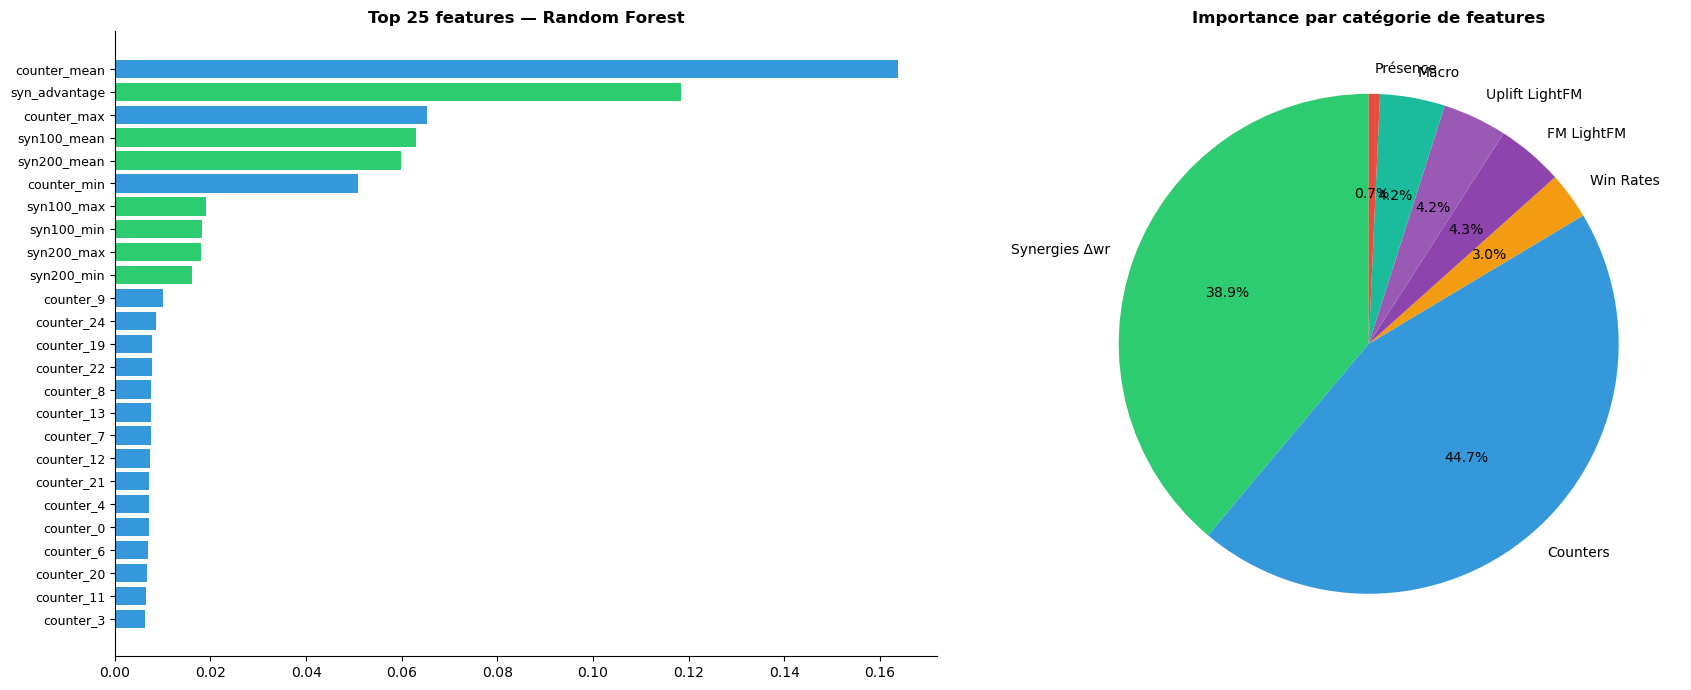

In [14]:
best_model = results[best_name]['model']
feat_names = (
    ['syn100_mean','syn100_min','syn100_max',
     'syn200_mean','syn200_min','syn200_max','syn_advantage',
     'counter_mean','counter_min','counter_max',
     'wr100_mean','wr200_mean','wr_advantage',
     # [NEW] LightFM
     'fm100_mean','fm200_mean','fm_advantage',
     'up100_mean','up200_mean','uplift_advantage',
     # [NEW] Macro
     'mac100_mean','mac200_mean','mac_advantage'] +
    [f'syn100_{i}' for i in range(10)] +
    [f'syn200_{i}' for i in range(10)] +
    [f'counter_{i}' for i in range(25)] +
    [f'wr100_{i}' for i in range(5)] +
    [f'wr200_{i}' for i in range(5)] +
    [f'fm100_{i}' for i in range(10)] +
    [f'fm200_{i}' for i in range(10)] +
    [f'up100_{i}' for i in range(10)] +
    [f'up200_{i}' for i in range(10)] +
    [f'mac100_{i}' for i in range(10)] +
    [f'mac200_{i}' for i in range(10)] +
    [f'presence_{c}' for c in sorted(fe.all_champions)]
)

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:25]
    top_names = [feat_names[i] if i < len(feat_names) else f'feat_{i}' for i in indices]

    def cat(n):
        if 'presence' in n: return 'Présence'
        if 'up' in n or 'uplift' in n: return 'Uplift LightFM'
        if 'fm' in n: return 'FM LightFM'
        if 'mac' in n: return 'Macro'
        if 'syn' in n: return 'Synergies Δwr'
        if 'counter' in n: return 'Counters'
        if 'wr' in n: return 'Win Rates'
        return 'Autre'

    color_map = {'Présence':'#e74c3c','Uplift LightFM':'#9b59b6',
                 'FM LightFM':'#8e44ad','Macro':'#1abc9c',
                 'Synergies Δwr':'#2ecc71','Counters':'#3498db','Win Rates':'#f39c12','Autre':'#95a5a6'}
    colors = [color_map[cat(n)] for n in top_names]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    axes[0].barh(range(len(indices)), importances[indices][::-1], color=colors[::-1])
    axes[0].set_yticks(range(len(indices)))
    axes[0].set_yticklabels(top_names[::-1], fontsize=9)
    axes[0].set_title(f'Top 25 features — {best_name}', fontweight='bold')

    cats_agg = defaultdict(float)
    for i, imp in enumerate(importances):
        n = feat_names[i] if i < len(feat_names) else ''
        cats_agg[cat(n)] += imp
    cats_agg = {k: v for k, v in cats_agg.items() if v > 0.001}
    axes[1].pie(cats_agg.values(), labels=cats_agg.keys(),
                colors=[color_map.get(k,'#95a5a6') for k in cats_agg],
                autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
    axes[1].set_title('Importance par catégorie de features', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print("Feature importance non disponible")

## 12. 🎯 Interface de Prédiction enrichie

La sortie inclut maintenant les **uplift synergies LightFM** et la **complémentarité macro** en plus des delta_wr classiques.


In [15]:
def predict_winner(team_blue: list, team_red: list, verbose=True) -> dict:
    assert len(team_blue) == 5 and len(team_red) == 5
    team_blue = [c.strip() for c in team_blue]
    team_red  = [c.strip() for c in team_red]

    unknown = [c for c in team_blue + team_red if c not in fe.all_champions]
    if unknown:
        print(f"⚠️  Champions inconnus : {unknown}")

    feat = fe._extract(team_blue, team_red)
    X    = np.array([feat], dtype=np.float32)

    probs_all  = {n: res['model'].predict_proba(X)[0][1] for n, res in results.items()}
    best_prob  = probs_all[best_name]
    consensus  = np.mean(list(probs_all.values()))
    winner     = '🔵 Team Bleue' if best_prob > 0.5 else '🔴 Team Rouge'
    confidence = abs(best_prob - 0.5) * 2

    # Synergy breakdown
    def syn_dict(team):
        out = {}
        for a, b in combinations(team, 2):
            k = f"{a}+{b}"
            out[k] = {
                'delta_wr': fe.synergy_wr(a, b),
                'uplift'  : fe.uplift_synergy(a, b),
                'fm'      : fe.fm_synergy(a, b),
                'macro'   : fe.macro_comp(a, b),
            }
        return out

    syn_blue = syn_dict(team_blue)
    syn_red  = syn_dict(team_red)

    counters = {}
    for a in team_blue:
        for b in team_red:
            wr = fe.counter_wr(a, b)
            games = fe.counter_stats.get((a, b), {}).get('games', 0)
            if abs(wr - 0.5) > 0.04 and games >= 30:
                counters[f"{a} vs {b}"] = wr

    result = dict(
        win_prob_blue=best_prob, win_prob_red=1-best_prob,
        winner=winner, confidence=confidence,
        probs_all=probs_all, consensus=consensus,
        syn_blue=syn_blue, syn_red=syn_red, counters=counters,
        wr_blue={c: fe.champ_wr(c) for c in team_blue},
        wr_red ={c: fe.champ_wr(c) for c in team_red},
    )

    if verbose:
        W = 66
        print("\n" + "=" * W)
        print("🎮  PRÉDICTION DRAFT — LEAGUE OF LEGENDS")
        print("=" * W)
        print(f"  🔵 Bleue : {', '.join(team_blue)}")
        print(f"  🔴 Rouge : {', '.join(team_red)}")
        print("-" * W)
        print(f"  🏆 Vainqueur prédit : {winner}")
        print(f"     Prob Bleue : {best_prob:.1%}  |  Prob Rouge : {1-best_prob:.1%}")
        print(f"     Confiance  : {confidence:.1%}  |  Consensus  : {consensus:.1%}")
        print("-" * W)

        def fmt_syn(label, syns):
            print(f"  {label}")
            sorted_pairs = sorted(syns.items(), key=lambda x: -(abs(x[1]['delta_wr']) + abs(x[1]['uplift'])))[:3]
            for pair, s in sorted_pairs:
                dwr = s['delta_wr']; up = s['uplift']; mac = s['macro']
                ico = "✅" if dwr > 0.02 or up > 0 else ("⚠️ " if dwr < -0.02 else "➖")
                print(f"     {ico} {pair:28s}  Δwr={dwr:+.1%}  uplift={up:+.3f}  macro={mac:+.2f}")

        fmt_syn("🤝 Top synergies Bleue :", syn_blue)
        fmt_syn("🤝 Top synergies Rouge :", syn_red)

        if counters:
            print(f"  ⚔️  Matchups clés (Bleue vs Rouge) :")
            for matchup, wr in sorted(counters.items(), key=lambda x: -x[1])[:5]:
                ico = "✅" if wr > 0.5 else "❌"
                print(f"     {ico} {matchup:34s}  WR={wr:.1%}")

        print(f"  📈 Win rates individuels :")
        print(f"     Bleue : " + "  ".join(f"{c}({fe.champ_wr(c):.0%})" for c in team_blue))
        print(f"     Rouge : " + "  ".join(f"{c}({fe.champ_wr(c):.0%})" for c in team_red))
        print("=" * W)

    return result

print("✅ predict_winner() enrichi prêt")

✅ predict_winner() enrichi prêt


### Exemple 1 — Engage vs Poke

In [16]:
result1 = predict_winner(
    ["Malphite", "Vi", "Orianna", "Jinx", "Thresh"],
    ["Jayce", "Graves", "Zed", "Caitlyn", "Karma"]
)


🎮  PRÉDICTION DRAFT — LEAGUE OF LEGENDS
  🔵 Bleue : Malphite, Vi, Orianna, Jinx, Thresh
  🔴 Rouge : Jayce, Graves, Zed, Caitlyn, Karma
------------------------------------------------------------------
  🏆 Vainqueur prédit : 🔵 Team Bleue
     Prob Bleue : 70.4%  |  Prob Rouge : 29.6%
     Confiance  : 40.8%  |  Consensus  : 79.4%
------------------------------------------------------------------
  🤝 Top synergies Bleue :
     ✅ Orianna+Jinx                  Δwr=+21.6%  uplift=-0.058  macro=-0.01
     ⚠️  Vi+Thresh                     Δwr=-5.0%  uplift=-0.129  macro=+0.02
     ✅ Malphite+Vi                   Δwr=+13.2%  uplift=-0.002  macro=-0.04
  🤝 Top synergies Rouge :
     ✅ Graves+Caitlyn                Δwr=+8.1%  uplift=-0.015  macro=+0.01
     ✅ Jayce+Zed                     Δwr=-5.1%  uplift=+0.026  macro=-0.02
     ✅ Graves+Karma                  Δwr=+2.6%  uplift=-0.042  macro=+0.01
  ⚔️  Matchups clés (Bleue vs Rouge) :
     ✅ Jinx vs Jayce                       WR=68.4%
   

### Exemple 2 — Compositions personnalisées

In [17]:
result2 = predict_winner(
    ["Fiora", "Hecarim", "TwistedFate", "Ezreal", "Lulu"],
    ["Garen", "Amumu", "Lux", "MissFortune", "Leona"]
)


🎮  PRÉDICTION DRAFT — LEAGUE OF LEGENDS
  🔵 Bleue : Fiora, Hecarim, TwistedFate, Ezreal, Lulu
  🔴 Rouge : Garen, Amumu, Lux, MissFortune, Leona
------------------------------------------------------------------
  🏆 Vainqueur prédit : 🔵 Team Bleue
     Prob Bleue : 55.2%  |  Prob Rouge : 44.8%
     Confiance  : 10.5%  |  Consensus  : 50.8%
------------------------------------------------------------------
  🤝 Top synergies Bleue :
     ⚠️  Hecarim+Ezreal                Δwr=-9.6%  uplift=-0.174  macro=-0.02
     ✅ TwistedFate+Lulu              Δwr=+4.1%  uplift=+0.224  macro=+0.01
     ✅ TwistedFate+Ezreal            Δwr=+16.9%  uplift=+0.077  macro=-0.01
  🤝 Top synergies Rouge :
     ✅ Lux+Leona                     Δwr=+51.4%  uplift=+0.072  macro=-0.00
     ✅ Amumu+MissFortune             Δwr=-27.2%  uplift=+0.066  macro=+0.00
     ✅ Garen+Leona                   Δwr=+9.0%  uplift=-0.144  macro=+0.01
  📈 Win rates individuels :
     Bleue : Fiora(50%)  Hecarim(48%)  TwistedFate(54%) 

### Visualisation enrichie

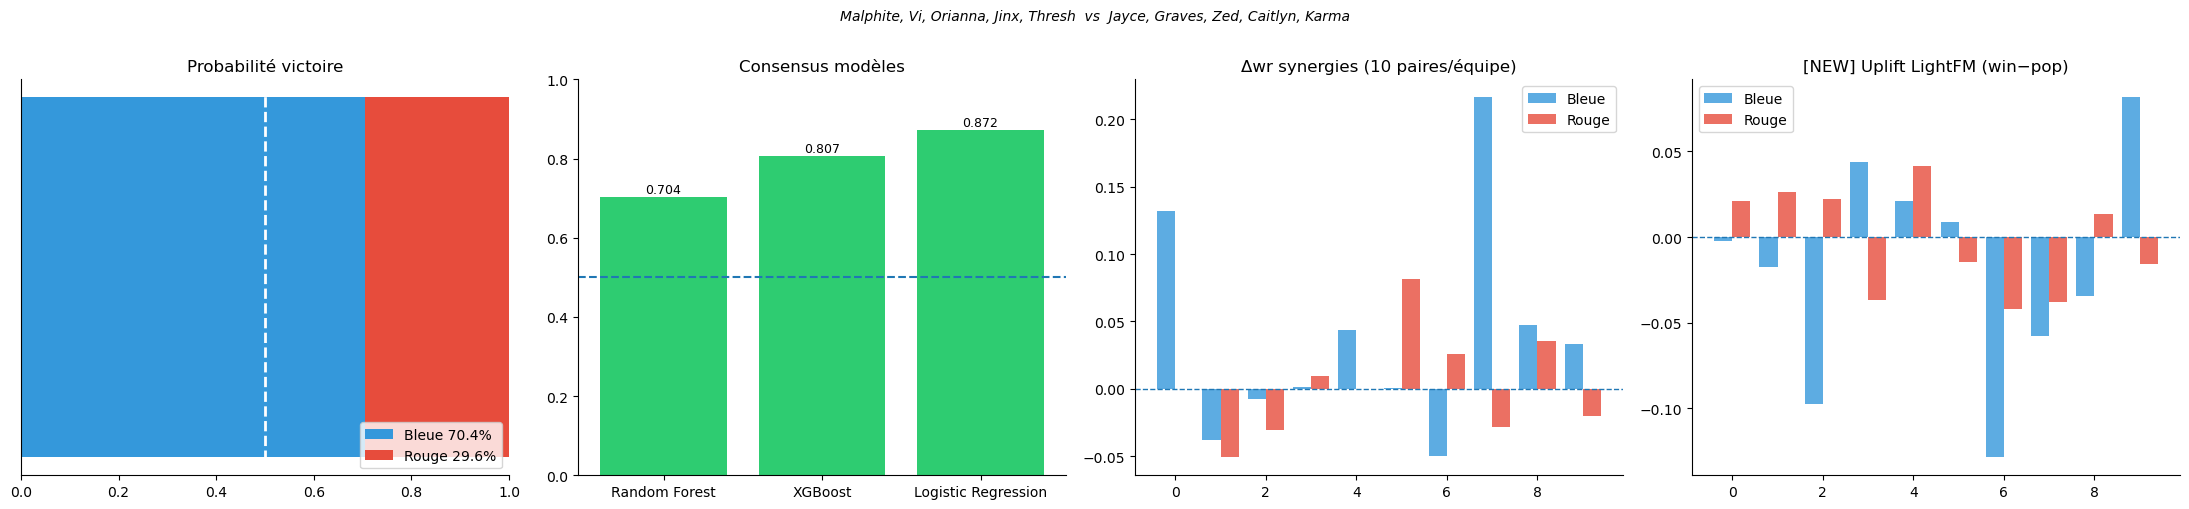

In [18]:
def plot_prediction_enriched(result, team_blue, team_red):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    # 1. Prob bar
    pb, pr = result['win_prob_blue'], result['win_prob_red']
    axes[0].barh([''], [pb], color='#3498db', label=f'Bleue {pb:.1%}')
    axes[0].barh([''], [pr], left=[pb], color='#e74c3c', label=f'Rouge {pr:.1%}')
    axes[0].axvline(0.5, color='white', lw=2, ls='--')
    axes[0].set_xlim(0,1); axes[0].set_title('Probabilité victoire')
    axes[0].legend(loc='lower right'); axes[0].set_yticks([])

    # 2. Model consensus
    mn = list(result['probs_all'].keys())
    mp = list(result['probs_all'].values())
    c  = ['#2ecc71' if p > 0.5 else '#e74c3c' for p in mp]
    axes[1].bar(mn, mp, color=c); axes[1].axhline(0.5, ls='--', lw=1.5)
    axes[1].set_ylim(0,1); axes[1].set_title('Consensus modèles')
    for i, (n, p) in enumerate(zip(mn, mp)):
        axes[1].text(i, p+0.01, f'{p:.3f}', ha='center', fontsize=9)

    # 3. Delta WR synergies (classique)
    dwr_b = [v['delta_wr'] for v in result['syn_blue'].values()]
    dwr_r = [v['delta_wr'] for v in result['syn_red'].values()]
    x = np.arange(len(dwr_b))
    axes[2].bar(x - 0.2, dwr_b, 0.4, color='#3498db', alpha=0.8, label='Bleue')
    axes[2].bar(x + 0.2, dwr_r, 0.4, color='#e74c3c', alpha=0.8, label='Rouge')
    axes[2].axhline(0, ls='--', lw=1); axes[2].set_title('Δwr synergies (10 paires/équipe)')
    axes[2].legend()

    # 4. [NEW] Uplift LightFM
    up_b = [v['uplift'] for v in result['syn_blue'].values()]
    up_r = [v['uplift'] for v in result['syn_red'].values()]
    axes[3].bar(x - 0.2, up_b, 0.4, color='#3498db', alpha=0.8, label='Bleue')
    axes[3].bar(x + 0.2, up_r, 0.4, color='#e74c3c', alpha=0.8, label='Rouge')
    axes[3].axhline(0, ls='--', lw=1); axes[3].set_title('[NEW] Uplift LightFM (win−pop)')
    axes[3].legend()

    plt.suptitle(f"{', '.join(team_blue)}  vs  {', '.join(team_red)}",
                 style='italic', fontsize=10, y=1.01)
    plt.tight_layout(); plt.show()

plot_prediction_enriched(
    result1,
    ["Malphite","Vi","Orianna","Jinx","Thresh"],
    ["Jayce","Graves","Zed","Caitlyn","Karma"]
)

## 13. 🔍 [NEW] Discovery Score — Synergies cachées

Inspiré de `Duos.ipynb` : classement combinant **Δwr + uplift + fm** pour révéler des duos statistiquement forts mais sous-représentés dans la méta.


In [19]:
def compute_discovery_scores(fe, min_games=30, top_k=20):
    """Calcule le discovery score pour toutes les paires de champions (train set)."""
    rows = []
    all_champs = sorted(fe.all_champions)
    for a, b in combinations(all_champs, 2):
        key = tuple(sorted([a, b]))
        s = fe.synergy_stats.get(key, {'wins': 0, 'games': 0})
        if s['games'] < min_games:
            continue
        dwr    = fe.synergy_wr(a, b)
        fm     = fe.fm_synergy(a, b)
        uplift = fe.uplift_synergy(a, b)
        rows.append({'a': a, 'b': b, 'games': s['games'],
                     'delta_wr': dwr, 'fm': fm, 'uplift': uplift})

    df_d = pd.DataFrame(rows)
    if df_d.empty:
        print("Pas assez de données."); return df_d

    def z(col): return (col - col.mean()) / (col.std() + 1e-9)

    df_d['z_dwr']    = z(df_d['delta_wr'])
    df_d['z_fm']     = z(df_d['fm'])
    df_d['z_uplift'] = z(df_d['uplift'])
    df_d['discovery_score'] = (
        0.5 * df_d['z_uplift'] +
        0.3 * df_d['z_fm']     +
        0.2 * df_d['z_dwr']
    )
    return df_d.sort_values('discovery_score', ascending=False)

disc_df = compute_discovery_scores(fe, min_games=30, top_k=20)
if not disc_df.empty:
    print("🔍 Top 20 duos découverts (fort uplift, potentiellement sous-côtés) :")
    print(disc_df.head(20)[['a','b','games','delta_wr','uplift','fm','discovery_score']]
          .to_string(index=False))

🔍 Top 20 duos découverts (fort uplift, potentiellement sous-côtés) :
         a           b  games  delta_wr   uplift       fm  discovery_score
     Varus      Velkoz     47  0.075585 0.274345 0.236148         3.191105
      Jinx    Volibear     32  0.064036 0.288288 0.188528         2.995440
     Riven    Tristana     42  0.077997 0.261192 0.118935         2.490393
     Poppy      Syndra     31  0.129273 0.227642 0.121646         2.430326
      Lulu TwistedFate     51  0.040631 0.223724 0.143632         2.280615
   Kalista        Lulu     33  0.271816 0.140874 0.107735         2.190792
     Talon      Thresh     40  0.052025 0.189702 0.158385         2.172855
   Ambessa         Mel     65 -0.018509 0.188974 0.184408         2.114342
     Sivir       Yasuo     58  0.113315 0.192527 0.109186         2.096334
 Gangplank        Lulu     45  0.011311 0.184973 0.163426         2.058495
   Alistar        Sion     55  0.116602 0.170446 0.126823         2.058073
   Hecarim       Varus     42  

## 14. Analyses complémentaires : counters & win rates

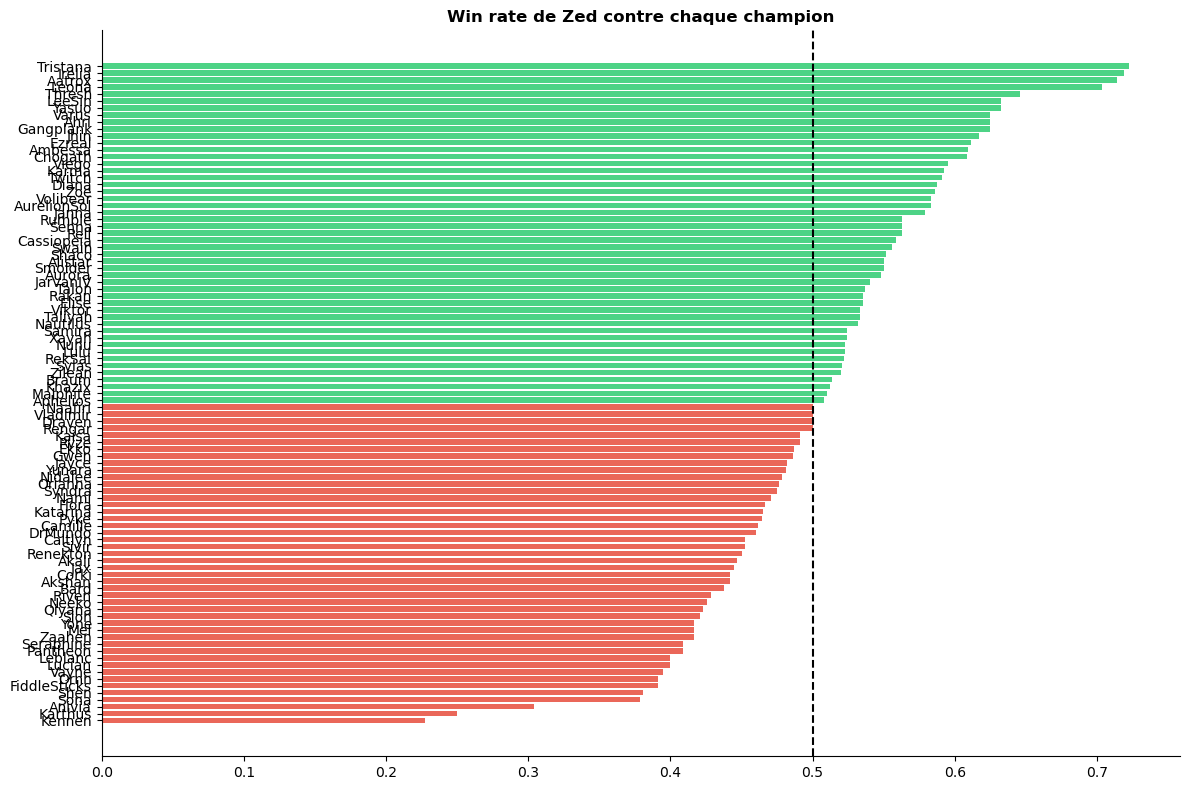

In [20]:
CHAMPION = "Zed"
rows = []
for (att, defn), s in fe.counter_stats.items():
    if att == CHAMPION and s['games'] >= 20:
        rows.append({'opponent': defn, 'win_rate': s['wins']/s['games'], 'games': s['games']})

if rows:
    cdf = pd.DataFrame(rows).sort_values('win_rate', ascending=False)
    fig, ax = plt.subplots(figsize=(12, 8))
    cols = ['#2ecc71' if w > 0.5 else '#e74c3c' for w in cdf['win_rate']]
    ax.barh(cdf['opponent'], cdf['win_rate'], color=cols, alpha=0.85)
    ax.axvline(0.5, color='black', lw=1.5, ls='--')
    ax.invert_yaxis()
    ax.set_title(f'Win rate de {CHAMPION} contre chaque champion', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print(f"'{CHAMPION}' absent ou données insuffisantes")

## 15. Sauvegarde du modèle

In [ ]:
print("emb_win est None ?", emb_win is None)
print("emb_pop est None ?", emb_pop is None)
print("lfm_item2id est vide ?", len(lfm_item2id) == 0)
if emb_win is not None:
    print("Forme emb_win:", emb_win.shape)
    print("Moyenne emb_win:", np.mean(emb_win))
    print("Écart-type emb_win:", np.std(emb_win))

In [ ]:
diff = emb_win - emb_pop
print("Différence moyenne :", np.mean(diff))
print("Différence écart-type :", np.std(diff))
print("Norme de la différence :", np.linalg.norm(diff))

# Tester sur une paire concrète
champ1, champ2 = "Malphite", "Yasuo"
if champ1 in lfm_item2id and champ2 in lfm_item2id:
    i1, i2 = lfm_item2id[champ1], lfm_item2id[champ2]
    dot_win = np.dot(emb_win[i1], emb_win[i2])
    dot_pop = np.dot(emb_pop[i1], emb_pop[i2])
    print(f"{champ1}+{champ2} : win_dot={dot_win:.4f}, pop_dot={dot_pop:.4f}, uplift={dot_win-dot_pop:.4f}")
else:
    print("Champions non trouvés dans lfm_item2id")

In [ ]:
save_data = {
    'fe': fe, 'models': models, 'results': results, 'best_name': best_name,
    # enrichers
    'emb_win': emb_win, 'emb_pop': emb_pop, 'lfm_item2id': lfm_item2id,
    'champ_style_vec': champ_style_vec
}
with open(MODEL_SAVE_PATH, 'wb') as f:
    pickle.dump(save_data, f)
print(f"💾 Modèle sauvegardé : {MODEL_SAVE_PATH}")

# ── Rechargement ──
# with open(MODEL_SAVE_PATH, 'rb') as f:
#     d = pickle.load(f)
# fe = DraftFeatureEngineering(
#     min_games=MIN_GAMES_FOR_STATS,
#     emb_win=d['emb_win'], emb_pop=d['emb_pop'], lfm_item2id=d['lfm_item2id'],
#     champ_style_vec=d['champ_style_vec']
# )
# fe.fitted = True
# fe.__dict__.update({k:v for k,v in d['fe'].__dict__.items() if k not in ('emb_win','emb_pop','lfm_item2id','champ_style_vec')})
# models, results, best_name = d['models'], d['results'], d['best_name']